In [1]:
# Download data from Zenodo (skip if already downloaded)
import os, sys
sys.path.insert(0, os.path.join(os.path.dirname('__file__'), '..', 'scripts'))
sys.path.insert(0, os.path.join(os.path.dirname('__file__'), '..', 'style'))
from download_data import download_all
from config import DATA_ROOT, EVENT_DATA_DIR, GLITCH_DIR

if not os.path.exists(os.path.join(EVENT_DATA_DIR, 'summary_statistics.h5')):
    download_all()
else:
    print(f'Data already present at {DATA_ROOT}')

Data already present at /work/nihargupte/analysis/dingo/asimov/eccentricity/working/release/code/notebooks/../scripts/../../zenodo_data


In [2]:
import os
import sys
sys.path.insert(0, os.path.join(os.path.dirname('__file__'), '..', 'scripts'))
sys.path.insert(0, os.path.join(os.path.dirname('__file__'), '..', 'style'))

import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from plot_style import COLORS, initialize_latex
from config import DATA_ROOT, EVENT_DATA_DIR, GLITCH_DIR

%matplotlib inline
initialize_latex()

In [3]:
# Load GW190701 posteriors
gw190701_path = os.path.join(GLITCH_DIR, 'GW190701.h5')
gw190701_glitch_marginalized_posterior = pd.read_hdf(gw190701_path, key='glitch_marginalized')
gw190701_non_glitch_marginalized_posterior = pd.read_hdf(gw190701_path, key='non_glitch_marginalized')
gw190701_hv_posterior = pd.read_hdf(gw190701_path, key='HV_only')

# Load glitch draws (list of eccentricity arrays from 100 glitch realizations)
with h5py.File(gw190701_path, 'r') as f:
    gw190701_glitch_draw_posterior = [f['glitch_draws'][str(i)][:] for i in range(len(f['glitch_draws']))]

# Load S231114n posteriors
s231114n_path = os.path.join(GLITCH_DIR, 'GW231114_043211.h5')
s231114n_glitch_marginalized_posterior = pd.read_hdf(s231114n_path, key='glitch_marginalized')
s231114n_non_glitch_marginalized_posterior = pd.read_hdf(s231114n_path, key='non_glitch_marginalized')
with h5py.File(s231114n_path, 'r') as f:
    s231114n_glitch_draw_posterior = [f['glitch_draws'][str(i)][:] for i in range(len(f['glitch_draws']))]

# Load S231223j posteriors
s231223j_path = os.path.join(GLITCH_DIR, 'GW231223_032836.h5')
s231223j_glitch_marginalized_posterior = pd.read_hdf(s231223j_path, key='glitch_marginalized')
s231223j_non_glitch_marginalized_posterior = pd.read_hdf(s231223j_path, key='non_glitch_marginalized')
with h5py.File(s231223j_path, 'r') as f:
    s231223j_glitch_draw_posterior = [f['glitch_draws'][str(i)][:] for i in range(len(f['glitch_draws']))]

print('Loaded glitch marginalization data for GW190701, S231114n, S231223j')

Loaded glitch marginalization data for GW190701, S231114n, S231223j


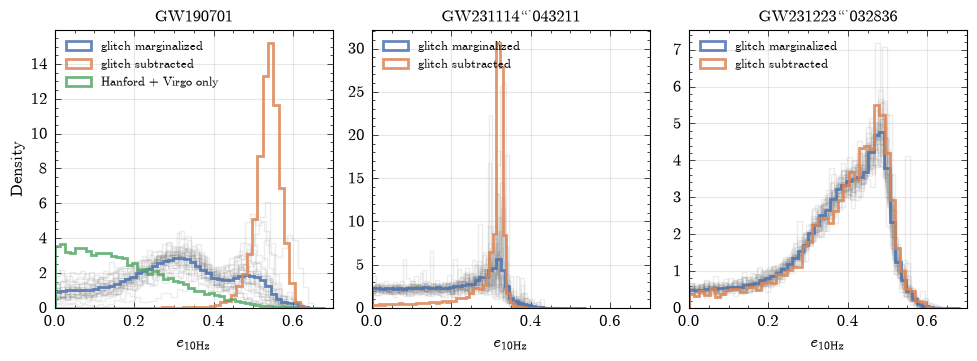

In [4]:
# Figure 2b: Three-event comparison with glitch-draw background
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
for ax in axes:
    ax.set_box_aspect(1)

bins = 50
xlim = (0.0, 0.7)

def plot_glitch_draws_background(ax, draw_list, bins, xlim):
    if not draw_list:
        return
    for arr in draw_list[:30]:
        x = np.asarray(arr)
        x = x[~np.isnan(x)]
        if x.size:
            ax.hist(x, bins=bins, density=True, alpha=0.15, color='gray', histtype='step')

# Event 1: GW190701
ax = axes[0]
plot_glitch_draws_background(ax, gw190701_glitch_draw_posterior, bins, xlim)
ax.hist(gw190701_glitch_marginalized_posterior['eccentricity'].dropna(),
        bins=bins, density=True, alpha=0.85, color=COLORS['blue'],
        label='glitch marginalized', linewidth=2, histtype='step')
ax.hist(gw190701_non_glitch_marginalized_posterior['eccentricity'].dropna(),
        bins=bins, density=True, alpha=0.85, color=COLORS['orange'],
        label='glitch subtracted', linewidth=2, histtype='step')
ax.hist(gw190701_hv_posterior['eccentricity'].dropna(),
        bins=bins, density=True, alpha=0.85, color=COLORS['green'],
        label='Hanford + Virgo only', linewidth=2, histtype='step')
ax.set_xlim(*xlim)
ax.set_xlabel('$e_{\\mathrm{10Hz}}$')
ax.set_ylabel('Density')
ax.set_title('GW190701')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9, loc='upper left')

# Event 2: GW231114_043211
ax = axes[1]
plot_glitch_draws_background(ax, s231114n_glitch_draw_posterior, bins, xlim)
ax.hist(s231114n_glitch_marginalized_posterior['eccentricity'].dropna(),
        bins=bins, density=True, alpha=0.85, color=COLORS['blue'],
        label='glitch marginalized', linewidth=2, histtype='step')
ax.hist(s231114n_non_glitch_marginalized_posterior['eccentricity'].dropna(),
        bins=bins, density=True, alpha=0.85, color=COLORS['orange'],
        label='glitch subtracted', linewidth=2, histtype='step')
ax.set_xlim(*xlim)
ax.set_xlabel('$e_{\\mathrm{10Hz}}$')
ax.set_title('GW231114\\_043211')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9, loc='upper left')

# Event 3: GW231223_032836
ax = axes[2]
plot_glitch_draws_background(ax, s231223j_glitch_draw_posterior, bins, xlim)
ax.hist(s231223j_glitch_marginalized_posterior['eccentricity'].dropna(),
        bins=bins, density=True, alpha=0.85, color=COLORS['blue'],
        label='glitch marginalized', linewidth=2, histtype='step')
ax.hist(s231223j_non_glitch_marginalized_posterior['eccentricity'].dropna(),
        bins=bins, density=True, alpha=0.85, color=COLORS['orange'],
        label='glitch subtracted', linewidth=2, histtype='step')
ax.set_xlim(*xlim)
ax.set_xlabel('$e_{\\mathrm{10Hz}}$')
ax.set_title('GW231223\\_032836')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig('../figures/three_event_glitch_comparison.pdf', dpi=300, bbox_inches='tight')